# Figure D: Robustness to Correlated Noise

This notebook tests PLS-SVD phase transition theory under **non-identity noise covariance**.
The standard theory (Theorem 3.2) assumes i.i.d. $\mathcal{N}(0,1)$ noise. We test two
structured noise covariance models:

1. **Toeplitz:** $(\Sigma_Z)_{ij} = r^{|i-j|}$ for $r \in \{0, 0.3, 0.6, 0.9\}$
2. **Factor model:** $\Sigma_Z = I + \sigma^2 F F^\top$, $F \in \mathbb{R}^{D_y \times 5}$

For each, we compare:
- **(a) Naive:** Apply PLS-SVD without noise whitening, compare to standard theory
- **(b) Whitened:** Whiten $Y$ by known $\Sigma_Z^{-1/2}$ before MCAR masking, compare to adjusted theory

**Message:** Naive application deviates under strong correlation; oracle whitening restores agreement.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import toeplitz
from tqdm.notebook import tqdm
import pickle
import os

from src.core import inv_sqrtm_psd

# ICML-compatible styling (matches existing notebooks)
plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

np.random.seed(42)

In [20]:
# ============================================================================
# Helper functions
# ============================================================================

def theta_crit_val(alpha_x, alpha_y, rho):
    """Critical signal strength for phase transition (Eq. 10)."""
    return 1.0 / ((alpha_x * alpha_y) ** 0.25 * np.sqrt(rho))


def theoretical_overlap_rx2(theta, alpha_x, alpha_y, rho):
    """Theoretical R_x^2 for a single component (Theorem 3.2, Eq. 8)."""
    disc = alpha_x * alpha_y * rho**2 * theta**4
    if disc <= 1:
        return 0.0
    return (disc - 1) / (alpha_y * rho * theta**2 * (alpha_x * rho * theta**2 + 1))


def sqrtm_psd(A, eps=1e-10):
    """Matrix square root of symmetric PSD matrix via eigendecomposition."""
    A_sym = (A + A.T) / 2
    w, V = np.linalg.eigh(A_sym)
    w = np.maximum(w, eps)
    return (V * np.sqrt(w)) @ V.T


def make_toeplitz_cov(Dy, r):
    """Toeplitz covariance: (Sigma)_{ij} = r^|i-j|."""
    return toeplitz(r ** np.arange(Dy))


def make_factor_cov(Dy, n_factors, sigma2, F):
    """Factor model covariance: Sigma = I + sigma^2 * F F^T."""
    return np.eye(Dy) + sigma2 * (F @ F.T)


def run_corr_noise_trial(N, Dx, Dy, theta, mx, my, Sigma_Z_sqrt, Sigma_Z_inv_sqrt,
                          alpha_x, alpha_y, rho, seed):
    """
    Single paired trial: naive and whitened PLS-SVD with correlated noise.
    
    Both conditions use the same X_star, u0, v0, Z_iid, and masks.
    Whitening is applied to Y_star BEFORE masking (oracle approach).
    """
    rng = np.random.default_rng(seed)
    
    # Generate whitened design X*
    G = rng.standard_normal((N, Dx))
    Q, _ = np.linalg.qr(G, mode='reduced')
    X_star = Q * np.sqrt(N)
    
    # Random signal directions
    u0 = rng.standard_normal(Dx)
    u0 /= np.linalg.norm(u0)
    v0 = rng.standard_normal(Dy)
    v0 /= np.linalg.norm(v0)
    
    # Generate i.i.d. noise, then correlate
    Z_iid = rng.standard_normal((N, Dy))
    signal = theta * np.outer(X_star @ u0, v0)
    Y_star_corr = signal + Z_iid @ Sigma_Z_sqrt
    
    # Whitened Y*: noise becomes i.i.d. again
    Y_star_whitened = Y_star_corr @ Sigma_Z_inv_sqrt
    
    # Effective theta after whitening
    v0_whitened = Sigma_Z_inv_sqrt @ v0
    theta_eff = theta * np.linalg.norm(v0_whitened)
    
    # MCAR masks (same for both conditions)
    Sx = rng.binomial(1, 1 - mx, size=(N, Dx))
    Sy = rng.binomial(1, 1 - my, size=(N, Dy))
    X_obs = Sx * X_star
    
    # --- Naive condition ---
    Y_obs_naive = Sy * Y_star_corr
    S_xx = (X_obs.T @ X_obs) / N
    A = inv_sqrtm_psd(S_xx)
    X_w = X_obs @ A
    C_naive = (X_w.T @ Y_obs_naive) / N
    U_n, _, _ = np.linalg.svd(C_naive, full_matrices=False)
    Rx2_naive = (U_n[:, 0] @ u0) ** 2
    
    # --- Whitened condition ---
    Y_obs_whitened = Sy * Y_star_whitened
    C_white = (X_w.T @ Y_obs_whitened) / N
    U_w, _, _ = np.linalg.svd(C_white, full_matrices=False)
    Rx2_whitened = (U_w[:, 0] @ u0) ** 2
    
    return {
        'Rx2_naive': Rx2_naive,
        'Rx2_whitened': Rx2_whitened,
        'theta_eff': theta_eff,
    }


def run_sweep(N, Dx, Dy, theta_values, mx, my, Sigma_Z_sqrt, Sigma_Z_inv_sqrt,
              alpha_x, alpha_y, rho, n_trials, desc=""):
    """Sweep over theta values, run n_trials per point, aggregate results."""
    n_sweep = len(theta_values)
    Rx2_naive_all = np.zeros((n_sweep, n_trials))
    Rx2_whitened_all = np.zeros((n_sweep, n_trials))
    theta_eff_all = np.zeros((n_sweep, n_trials))
    
    for j, theta in enumerate(tqdm(theta_values, desc=desc)):
        for trial in range(n_trials):
            result = run_corr_noise_trial(
                N, Dx, Dy, theta, mx, my, Sigma_Z_sqrt, Sigma_Z_inv_sqrt,
                alpha_x, alpha_y, rho, seed=trial * 10000 + j)
            Rx2_naive_all[j, trial] = result['Rx2_naive']
            Rx2_whitened_all[j, trial] = result['Rx2_whitened']
            theta_eff_all[j, trial] = result['theta_eff']
    
    # Theory: standard (for naive) and per-trial adjusted (for whitened)
    theory_naive = np.array([theoretical_overlap_rx2(th, alpha_x, alpha_y, rho)
                             for th in theta_values])
    
    # Per-trial adjusted theory for whitened: use theta_eff per trial
    theory_whitened_per_trial = np.zeros((n_sweep, n_trials))
    for j in range(n_sweep):
        for trial in range(n_trials):
            theory_whitened_per_trial[j, trial] = theoretical_overlap_rx2(
                theta_eff_all[j, trial], alpha_x, alpha_y, rho)
    
    return {
        'Rx2_naive_mean': Rx2_naive_all.mean(axis=1),
        'Rx2_naive_std': Rx2_naive_all.std(axis=1),
        'Rx2_whitened_mean': Rx2_whitened_all.mean(axis=1),
        'Rx2_whitened_std': Rx2_whitened_all.std(axis=1),
        'theory_naive': theory_naive,
        'theory_whitened_mean': theory_whitened_per_trial.mean(axis=1),
        'theta_eff_mean': theta_eff_all.mean(axis=1),
    }


print("Helper functions defined.")

Helper functions defined.


In [21]:
# ============================================================================
# Shared parameters
# ============================================================================
N = 1000
Dx = 200
Dy = 150
mx = my = 0.3
n_trials = 100

alpha_x = N / Dx
alpha_y = N / Dy
rho = (1 - mx) * (1 - my)
theta_crit = theta_crit_val(alpha_x, alpha_y, rho)
theta_values = np.linspace(0.5 * theta_crit, 2.5 * theta_crit, 25)

print(f"Parameters: N={N}, Dx={Dx}, Dy={Dy}, mx={mx}, my={my}")
print(f"  alpha_x={alpha_x:.3f}, alpha_y={alpha_y:.3f}, rho={rho:.3f}")
print(f"  theta_crit={theta_crit:.4f}, n_trials={n_trials}")

results_dir = '../results'
os.makedirs(results_dir, exist_ok=True)
cache_file = os.path.join(results_dir, 'figD_correlated_noise_results.pkl')

Parameters: N=1000, Dx=200, Dy=150, mx=0.3, my=0.3
  alpha_x=5.000, alpha_y=6.667, rho=0.490
  theta_crit=0.5945, n_trials=100


## Experiment 1: Toeplitz Noise Covariance

$(\Sigma_Z)_{ij} = r^{|i-j|}$ for $r \in \{0, 0.3, 0.6, 0.9\}$. Condition number $\kappa \approx (1+r)/(1-r)$.

In [22]:
# ============================================================================
# EXPERIMENT 1: Toeplitz noise covariance
# ============================================================================

if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        all_results = pickle.load(f)
else:
    all_results = {}

r_values = [0.0, 0.3, 0.6, 0.9]

if 'toeplitz' in all_results:
    print("Loading Toeplitz results from cache...")
    toeplitz_results = all_results['toeplitz']
    print(f"  Loaded! r values = {list(toeplitz_results['sweeps'].keys())}\n")
else:
    print("Running Toeplitz correlated noise experiment...")
    toeplitz_results = {'sweeps': {}, 'cond_numbers': {}}

    for r in r_values:
        Sigma_Z = make_toeplitz_cov(Dy, r)
        cond = np.linalg.cond(Sigma_Z)
        toeplitz_results['cond_numbers'][r] = cond

        if r == 0.0:
            Sigma_Z_sqrt = np.eye(Dy)
            Sigma_Z_inv_sqrt = np.eye(Dy)
        else:
            Sigma_Z_sqrt = sqrtm_psd(Sigma_Z)
            Sigma_Z_inv_sqrt = inv_sqrtm_psd(Sigma_Z)

        print(f"  r={r}, cond(Sigma_Z)={cond:.2f}")
        result = run_sweep(N, Dx, Dy, theta_values, mx, my,
                           Sigma_Z_sqrt, Sigma_Z_inv_sqrt,
                           alpha_x, alpha_y, rho, n_trials,
                           desc=f"    r={r}")
        toeplitz_results['sweeps'][r] = result

    toeplitz_results['r_values'] = r_values
    toeplitz_results['theta_values'] = theta_values
    all_results['toeplitz'] = toeplitz_results

    with open(cache_file, 'wb') as f:
        pickle.dump(all_results, f)
    print("  Done! Results saved.\n")

Loading Toeplitz results from cache...
  Loaded! r values = [0.0, 0.3, 0.6, 0.9]



In [23]:
# Toeplitz text results
print("Toeplitz Noise Covariance Results (R_x^2)")
theta_norm = theta_values / theta_crit
mask_super = theta_norm > 1.1  # supercritical regime for MAE

for r in r_values:
    s = toeplitz_results['sweeps'][r]
    cond = toeplitz_results['cond_numbers'][r]
    mae_naive = np.mean(np.abs(s['Rx2_naive_mean'][mask_super] - s['theory_naive'][mask_super]))
    mae_white = np.mean(np.abs(s['Rx2_whitened_mean'][mask_super] - s['theory_whitened_mean'][mask_super]))
    print(f"\n  r={r}, cond(Sigma_Z)={cond:.2f}, MAE naive={mae_naive:.4f}, MAE whitened={mae_white:.4f}")
    print(f"  {'theta/theta_c':>13s}  {'Naive':>8s}  {'Whitened':>8s}  {'Thy(naive)':>10s}  {'Thy(white)':>10s}")
    print("  " + "-" * 58)
    for j in range(len(theta_values)):
        print(f"  {theta_norm[j]:13.3f}  {s['Rx2_naive_mean'][j]:8.4f}  {s['Rx2_whitened_mean'][j]:8.4f}  {s['theory_naive'][j]:10.4f}  {s['theory_whitened_mean'][j]:10.4f}")

Toeplitz Noise Covariance Results (R_x^2)

  r=0.0, cond(Sigma_Z)=1.00, MAE naive=0.0165, MAE whitened=0.0165
  theta/theta_c     Naive  Whitened  Thy(naive)  Thy(white)
  ----------------------------------------------------------
          0.500    0.0101    0.0101      0.0000      0.0000
          0.583    0.0135    0.0135      0.0000      0.0000
          0.667    0.0210    0.0210      0.0000      0.0000
          0.750    0.0359    0.0359      0.0000      0.0000
          0.833    0.0522    0.0522      0.0000      0.0000
          0.917    0.0683    0.0683      0.0000      0.0000
          1.000    0.1236    0.1236      0.0000      0.0000
          1.083    0.1869    0.1869      0.1381      0.1381
          1.167    0.2703    0.2703      0.2490      0.2490
          1.250    0.3379    0.3379      0.3395      0.3395
          1.333    0.4207    0.4207      0.4144      0.4144
          1.417    0.4854    0.4854      0.4772      0.4772
          1.500    0.5345    0.5345      0.5303  

## Experiment 2: Factor Model Noise Covariance

$\Sigma_Z = I + \sigma^2 F F^\top$, $F \in \mathbb{R}^{D_y \times 5}$ with Gaussian entries (fixed across trials).

In [24]:
# ============================================================================
# EXPERIMENT 2: Factor model noise covariance
# ============================================================================

if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        all_results = pickle.load(f)

sigma2_values = [0.0, 1.0, 3.0, 10.0]

# Fixed factor loading matrix F (Dy x 5)
rng_F = np.random.default_rng(123)
F_matrix = rng_F.standard_normal((Dy, 5))

if 'factor' in all_results:
    print("Loading factor model results from cache...")
    factor_results = all_results['factor']
    print(f"  Loaded! sigma^2 values = {list(factor_results['sweeps'].keys())}\n")
else:
    print("Running factor model correlated noise experiment...")
    factor_results = {'sweeps': {}, 'cond_numbers': {}}

    for sigma2 in sigma2_values:
        if sigma2 == 0.0:
            Sigma_Z = np.eye(Dy)
            Sigma_Z_sqrt = np.eye(Dy)
            Sigma_Z_inv_sqrt = np.eye(Dy)
        else:
            Sigma_Z = make_factor_cov(Dy, 5, sigma2, F_matrix)
            Sigma_Z_sqrt = sqrtm_psd(Sigma_Z)
            Sigma_Z_inv_sqrt = inv_sqrtm_psd(Sigma_Z)

        cond = np.linalg.cond(Sigma_Z)
        factor_results['cond_numbers'][sigma2] = cond

        print(f"  sigma^2={sigma2}, cond(Sigma_Z)={cond:.2f}")
        result = run_sweep(N, Dx, Dy, theta_values, mx, my,
                           Sigma_Z_sqrt, Sigma_Z_inv_sqrt,
                           alpha_x, alpha_y, rho, n_trials,
                           desc=f"    s2={sigma2}")
        factor_results['sweeps'][sigma2] = result

    factor_results['sigma2_values'] = sigma2_values
    factor_results['theta_values'] = theta_values
    all_results['factor'] = factor_results

    with open(cache_file, 'wb') as f:
        pickle.dump(all_results, f)
    print("  Done! Results saved.\n")

Loading factor model results from cache...
  Loaded! sigma^2 values = [0.0, 1.0, 3.0, 10.0]



In [25]:
# Factor model text results
print("Factor Model Noise Covariance Results (R_x^2)")
mask_super = theta_norm > 1.1

for sigma2 in sigma2_values:
    s = factor_results['sweeps'][sigma2]
    cond = factor_results['cond_numbers'][sigma2]
    mae_naive = np.mean(np.abs(s['Rx2_naive_mean'][mask_super] - s['theory_naive'][mask_super]))
    mae_white = np.mean(np.abs(s['Rx2_whitened_mean'][mask_super] - s['theory_whitened_mean'][mask_super]))
    print(f"\n  sigma^2={sigma2}, cond(Sigma_Z)={cond:.2f}, MAE naive={mae_naive:.4f}, MAE whitened={mae_white:.4f}")
    print(f"  {'theta/theta_c':>13s}  {'Naive':>8s}  {'Whitened':>8s}  {'Thy(naive)':>10s}  {'Thy(white)':>10s}")
    print("  " + "-" * 58)
    for j in range(len(theta_values)):
        print(f"  {theta_norm[j]:13.3f}  {s['Rx2_naive_mean'][j]:8.4f}  {s['Rx2_whitened_mean'][j]:8.4f}  {s['theory_naive'][j]:10.4f}  {s['theory_whitened_mean'][j]:10.4f}")

Factor Model Noise Covariance Results (R_x^2)

  sigma^2=0.0, cond(Sigma_Z)=1.00, MAE naive=0.0165, MAE whitened=0.0165
  theta/theta_c     Naive  Whitened  Thy(naive)  Thy(white)
  ----------------------------------------------------------
          0.500    0.0101    0.0101      0.0000      0.0000
          0.583    0.0135    0.0135      0.0000      0.0000
          0.667    0.0210    0.0210      0.0000      0.0000
          0.750    0.0359    0.0359      0.0000      0.0000
          0.833    0.0522    0.0522      0.0000      0.0000
          0.917    0.0683    0.0683      0.0000      0.0000
          1.000    0.1236    0.1236      0.0000      0.0000
          1.083    0.1869    0.1869      0.1381      0.1381
          1.167    0.2703    0.2703      0.2490      0.2490
          1.250    0.3379    0.3379      0.3395      0.3395
          1.333    0.4207    0.4207      0.4144      0.4144
          1.417    0.4854    0.4854      0.4772      0.4772
          1.500    0.5345    0.5345    

## Composite Figure

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


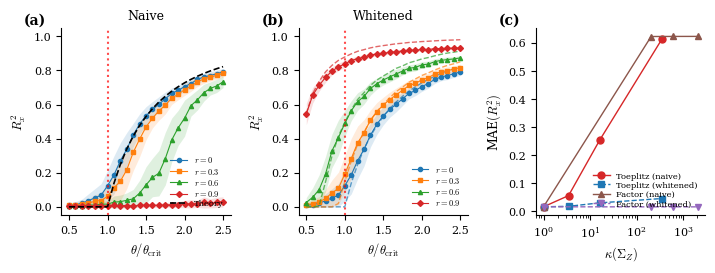


Figure saved: ../figures/figD_correlated_noise.pdf


In [26]:
# ============================================================================
# COMPOSITE 3-PANEL FIGURE
# ============================================================================

fig = plt.figure(figsize=(7.0, 2.5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1],
                       wspace=0.40, left=0.06, right=0.98,
                       bottom=0.17, top=0.92)

ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])
ax_c = fig.add_subplot(gs[2])

theta_norm = theta_values / theta_crit
mask_super = theta_norm > 1.1

toeplitz_meta = {
    0.0: {'color': 'C0', 'marker': 'o', 'label': r'$r = 0$'},
    0.3: {'color': 'C1', 'marker': 's', 'label': r'$r = 0.3$'},
    0.6: {'color': 'C2', 'marker': '^', 'label': r'$r = 0.6$'},
    0.9: {'color': 'C3', 'marker': 'D', 'label': r'$r = 0.9$'},
}

# ============================================================================
# PANEL (a): Toeplitz — Naive PLS-SVD
# ============================================================================
for r in r_values:
    s = toeplitz_results['sweeps'][r]
    m = toeplitz_meta[r]
    ax_a.plot(theta_norm, s['Rx2_naive_mean'], f'{m["marker"]}-',
              markersize=3, linewidth=0.8, color=m['color'], label=m['label'])
    ax_a.fill_between(theta_norm,
                       s['Rx2_naive_mean'] - s['Rx2_naive_std'],
                       s['Rx2_naive_mean'] + s['Rx2_naive_std'],
                       color=m['color'], alpha=0.15, linewidth=0)

# Standard theory (same for all r)
ax_a.plot(theta_norm, toeplitz_results['sweeps'][0.0]['theory_naive'],
          'k--', linewidth=1.2, label='Theory')
ax_a.axvline(1.0, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax_a.set_xlabel(r'$\theta / \theta_{\mathrm{crit}}$')
ax_a.set_ylabel(r'$R_x^2$')
ax_a.set_ylim([-0.05, 1.05])
ax_a.set_title('Naive', fontsize=9)
ax_a.legend(loc='lower right', frameon=False, labelspacing=0.15, fontsize=6)
ax_a.text(-0.22, 1.08, '(a)', transform=ax_a.transAxes,
          fontsize=10, fontweight='bold', va='top')

# ============================================================================
# PANEL (b): Toeplitz — Whitened PLS-SVD
# ============================================================================
for r in r_values:
    s = toeplitz_results['sweeps'][r]
    m = toeplitz_meta[r]
    ax_b.plot(theta_norm, s['Rx2_whitened_mean'], f'{m["marker"]}-',
              markersize=3, linewidth=0.8, color=m['color'], label=m['label'])
    ax_b.fill_between(theta_norm,
                       s['Rx2_whitened_mean'] - s['Rx2_whitened_std'],
                       s['Rx2_whitened_mean'] + s['Rx2_whitened_std'],
                       color=m['color'], alpha=0.15, linewidth=0)
    # Per-r adjusted theory
    ax_b.plot(theta_norm, s['theory_whitened_mean'], '--',
              color=m['color'], linewidth=1.0, alpha=0.7)

ax_b.axvline(1.0, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax_b.set_xlabel(r'$\theta / \theta_{\mathrm{crit}}$')
ax_b.set_ylabel(r'$R_x^2$')
ax_b.set_ylim([-0.05, 1.05])
ax_b.set_title('Whitened', fontsize=9)
ax_b.legend(loc='lower right', frameon=False, labelspacing=0.15, fontsize=6)
ax_b.text(-0.22, 1.08, '(b)', transform=ax_b.transAxes,
          fontsize=10, fontweight='bold', va='top')

# ============================================================================
# PANEL (c): MAE vs condition number
# ============================================================================
# Toeplitz points
conds_t = [toeplitz_results['cond_numbers'][r] for r in r_values]
mae_naive_t = []
mae_white_t = []
for r in r_values:
    s = toeplitz_results['sweeps'][r]
    mae_naive_t.append(np.mean(np.abs(s['Rx2_naive_mean'][mask_super] - s['theory_naive'][mask_super])))
    mae_white_t.append(np.mean(np.abs(s['Rx2_whitened_mean'][mask_super] - s['theory_whitened_mean'][mask_super])))

ax_c.plot(conds_t, mae_naive_t, 'o-', color='C3', markersize=5, linewidth=1.0,
          label='Toeplitz (naive)')
ax_c.plot(conds_t, mae_white_t, 's--', color='C0', markersize=5, linewidth=1.0,
          label='Toeplitz (whitened)')

# Factor model points
conds_f = [factor_results['cond_numbers'][s2] for s2 in sigma2_values]
mae_naive_f = []
mae_white_f = []
for sigma2 in sigma2_values:
    s = factor_results['sweeps'][sigma2]
    mae_naive_f.append(np.mean(np.abs(s['Rx2_naive_mean'][mask_super] - s['theory_naive'][mask_super])))
    mae_white_f.append(np.mean(np.abs(s['Rx2_whitened_mean'][mask_super] - s['theory_whitened_mean'][mask_super])))

ax_c.plot(conds_f, mae_naive_f, '^-', color='C5', markersize=5, linewidth=1.0,
          label='Factor (naive)')
ax_c.plot(conds_f, mae_white_f, 'v--', color='C4', markersize=5, linewidth=1.0,
          label='Factor (whitened)')

ax_c.set_xlabel(r'$\kappa(\Sigma_Z)$')
ax_c.set_ylabel(r'MAE$(R_x^2)$')
ax_c.set_xscale('log')
ax_c.legend(loc='lower right', frameon=False, labelspacing=0.15, fontsize=6)
ax_c.text(-0.22, 1.08, '(c)', transform=ax_c.transAxes,
          fontsize=10, fontweight='bold', va='top')

# ============================================================================
# Save
# ============================================================================
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/figD_correlated_noise.pdf',
            dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("Figure saved: ../figures/figD_correlated_noise.pdf")
print("=" * 70)

## Summary

In [27]:
# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print("=" * 70)
print("CORRELATED NOISE ROBUSTNESS: SUMMARY")
print("=" * 70)

print("\nTOEPLITZ NOISE:")
print(f"  {'r':>6s}  {'cond(Sigma)':>12s}  {'MAE naive':>10s}  {'MAE whitened':>12s}")
print("  " + "-" * 45)
for r in r_values:
    s = toeplitz_results['sweeps'][r]
    cond = toeplitz_results['cond_numbers'][r]
    mae_n = np.mean(np.abs(s['Rx2_naive_mean'][mask_super] - s['theory_naive'][mask_super]))
    mae_w = np.mean(np.abs(s['Rx2_whitened_mean'][mask_super] - s['theory_whitened_mean'][mask_super]))
    print(f"  {r:6.1f}  {cond:12.2f}  {mae_n:10.4f}  {mae_w:12.4f}")

print("\nFACTOR MODEL NOISE:")
print(f"  {'sigma^2':>8s}  {'cond(Sigma)':>12s}  {'MAE naive':>10s}  {'MAE whitened':>12s}")
print("  " + "-" * 47)
for sigma2 in sigma2_values:
    s = factor_results['sweeps'][sigma2]
    cond = factor_results['cond_numbers'][sigma2]
    mae_n = np.mean(np.abs(s['Rx2_naive_mean'][mask_super] - s['theory_naive'][mask_super]))
    mae_w = np.mean(np.abs(s['Rx2_whitened_mean'][mask_super] - s['theory_whitened_mean'][mask_super]))
    print(f"  {sigma2:8.1f}  {cond:12.2f}  {mae_n:10.4f}  {mae_w:12.4f}")

# Compute worst-case MAEs
worst_naive_t = max(np.mean(np.abs(toeplitz_results['sweeps'][r]['Rx2_naive_mean'][mask_super] -
                   toeplitz_results['sweeps'][r]['theory_naive'][mask_super])) for r in r_values)
worst_naive_f = max(np.mean(np.abs(factor_results['sweeps'][s2]['Rx2_naive_mean'][mask_super] -
                   factor_results['sweeps'][s2]['theory_naive'][mask_super])) for s2 in sigma2_values)
worst_white_t = max(np.mean(np.abs(toeplitz_results['sweeps'][r]['Rx2_whitened_mean'][mask_super] -
                   toeplitz_results['sweeps'][r]['theory_whitened_mean'][mask_super])) for r in r_values)
worst_white_f = max(np.mean(np.abs(factor_results['sweeps'][s2]['Rx2_whitened_mean'][mask_super] -
                   factor_results['sweeps'][s2]['theory_whitened_mean'][mask_super])) for s2 in sigma2_values)

print(f"\nWorst-case naive MAE:    Toeplitz={worst_naive_t:.4f}, Factor={worst_naive_f:.4f}")
print(f"Worst-case whitened MAE: Toeplitz={worst_white_t:.4f}, Factor={worst_white_f:.4f}")

print("\n" + "=" * 70)
print("CONCLUSION: Standard theory deviates under strong noise correlation")
print("(naive MAE grows with condition number). Oracle whitening of Y by")
print("Sigma_Z^{-1/2} before masking restores agreement with adjusted theory")
print("(whitened MAE remains low across all conditions).")
print("=" * 70)

CORRELATED NOISE ROBUSTNESS: SUMMARY

TOEPLITZ NOISE:
       r   cond(Sigma)   MAE naive  MAE whitened
  ---------------------------------------------
     0.0          1.00      0.0165        0.0165
     0.3          3.45      0.0564        0.0182
     0.6         15.97      0.2532        0.0305
     0.9        350.05      0.6143        0.0461

FACTOR MODEL NOISE:
   sigma^2   cond(Sigma)   MAE naive  MAE whitened
  -----------------------------------------------
       0.0          1.00      0.0165        0.0165
       1.0        204.78      0.6232        0.0163
       3.0        612.33      0.6235        0.0163
      10.0       2038.76      0.6236        0.0163

Worst-case naive MAE:    Toeplitz=0.6143, Factor=0.6236
Worst-case whitened MAE: Toeplitz=0.0461, Factor=0.0165

CONCLUSION: Standard theory deviates under strong noise correlation
(naive MAE grows with condition number). Oracle whitening of Y by
Sigma_Z^{-1/2} before masking restores agreement with adjusted theory
(whitened